# District-Wise Public Distribution System (PDS) Analysis: Monthly Wheat and Rice Allocation vs Distribution


### Overview:
The district-wise Public Distribution System (PDS) dataset provides inforamtion on the monthly distribution of food grains such as rice and wheat to eligible households through the PDS. The dataset covers 500 records with 9 attributes for the period 2017-2021. This analysis aims to evaluate the efficiency of the PDS by comparing allocations with actual distribution of food  grains and to identify the states and districts that perform best and tworst in terms of delivery effectiveness.

### Import important Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [2]:
df =pd.read_csv(r"C:\Users\DHANYA\Downloads\PDS District Wise Monthly Wheat and Rice_Sample_Data.csv")
print("Dataset is loaded successfully!")

Dataset is loaded successfully!


In [4]:
df.head()

,Month (month),State (state_name),State Code (state_code),District (district_name),District Code (district_code),Total Rice Allocated (total_rice_allocated),Total Wheat Allocated (total_wheat_allocated),Total Rice Distributed (total_rice_distributed),Total Wheat Distritibuted (total_wheat_distributed)
0,2019-03-01,Maharashtra,27,Pune,490,14752.37,22020.04,7063.01,10578.46
1,2020-07-01,Odisha,21,Cuttack,350,7211.43,2553.01,7200.06,2549.06
2,2017-12-01,Madhya Pradesh,23,Guna,406,949.63,4181.15,655.16,2821.86
3,2020-07-01,Maharashtra,27,Buldana,472,3990.65,5823.88,3806.86,5559.92
4,2019-03-01,Tamil Nadu,33,Ramanathapuram,583,4964.87,140.05,4346.32,114.97


In [5]:
df.shape

(500, 9)

In [7]:
# Summary of Dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Month (month)                                        500 non-null    object 
 1   State (state_name)                                   500 non-null    object 
 2   State Code (state_code)                              500 non-null    int64  
 3   District (district_name)                             500 non-null    object 
 4   District Code (district_code)                        500 non-null    int64  
 5   Total Rice Allocated (total_rice_allocated)          500 non-null    float64
 6   Total Wheat Allocated (total_wheat_allocated)        500 non-null    float64
 7   Total Rice Distributed (total_rice_distributed)      500 non-null    float64
 8   Total Wheat Distritibuted (total_wheat_distributed)  500 non-null    fl

### Data Cleaning

In [16]:
# Changing data types
df['Month (month)'] = pd.to_datetime(df['Month (month)'], dayfirst=True, errors='coerce')

In [18]:
#Checking data types
df.dtypes

Month (month)                                          datetime64[ns]
State (state_name)                                             object
State Code (state_code)                                         int64
District (district_name)                                       object
District Code (district_code)                                   int64
Total Rice Allocated (total_rice_allocated)                   float64
Total Wheat Allocated (total_wheat_allocated)                 float64
Total Rice Distributed (total_rice_distributed)               float64
Total Wheat Distritibuted (total_wheat_distributed)           float64
dtype: object

In [19]:
# Handling missing values
df.isnull().sum()

Month (month)                                          0
State (state_name)                                     0
State Code (state_code)                                0
District (district_name)                               0
District Code (district_code)                          0
Total Rice Allocated (total_rice_allocated)            0
Total Wheat Allocated (total_wheat_allocated)          0
Total Rice Distributed (total_rice_distributed)        0
Total Wheat Distritibuted (total_wheat_distributed)    0
dtype: int64

In [21]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

### Statiscal Summary of Relevant Numerical Columns

In [23]:
relevant_cols =['Total Rice Allocated (total_rice_allocated)','Total Wheat Allocated (total_wheat_allocated)','Total Rice Distributed (total_rice_distributed)','Total Wheat Distritibuted (total_wheat_distributed)']
df[relevant_cols].describe()

,Total Rice Allocated (total_rice_allocated),Total Wheat Allocated (total_wheat_allocated),Total Rice Distributed (total_rice_distributed),Total Wheat Distritibuted (total_wheat_distributed)
count,500.000000,500.000000,500.000000,500.000000
mean,4031.840340,3049.792080,3206.012840,2257.579280
std,4512.767814,5065.575196,3250.452222,3086.491239
min,0.000000,0.000000,0.000000,0.000000
25%,813.487500,0.000000,539.662500,0.000000
50%,2824.285000,955.880000,2421.525000,626.815000
75%,5526.547500,4378.672500,4838.077500,3588.815000
max,40390.070000,66225.130000,18446.040000,18628.500000


### Uncovering important questions through Exploratory Data Analysis (EDA)

#### 1. What is the average efficiency of rice and wheat distribution?
- Since Efficiency = Distribution/Allocation

In [26]:
# Efficiency of Rice distribution:
df['Efficiency of Rice distribution'] = df['Total Rice Distributed (total_rice_distributed)']/df['Total Rice Allocated (total_rice_allocated)'] 
df['Efficiency of Rice distribution']

0      0.478771
1      0.998423
2      0.689911
3      0.953945
4      0.875415
         ...   
495         NaN
496         NaN
497         NaN
498    0.896803
499    0.559238
Name: Efficiency of Rice distribution, Length: 500, dtype: float64


In [27]:
print("Average Efficiency of Rice distribution:",df['Efficiency of Rice distribution'].mean())

Average Efficiency of Rice distribution: 0.857667457204652


In [29]:
# Efficiency in Wheat Distribution
df['Efficiency in What distribution'] = df['Total Wheat Distritibuted (total_wheat_distributed)']/df['Total Wheat Allocated (total_wheat_allocated)']

In [32]:
print("Average Efficiency of Wheat distribution:", df['Efficiency in What distribution'].mean())

Average Efficiency of Wheat distribution: inf


In [33]:
# Replace infinities With Nan
df['Efficiency in What distribution'].replace([np.inf,-np.inf],np.nan,inplace = True)

C:\Users\DHANYA\AppData\Local\Temp\ipykernel_4408\37377126.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Efficiency in What distribution'].replace([np.inf,-np.inf],np.nan,inplace = True)


In [34]:
# Compute average safely
avg_wheat_efficiency = df['Efficiency in What distribution'].mean()

In [35]:
print("Average Efficency of Wheat distribution:", avg_wheat_efficiency)

Average Efficency of Wheat distribution: 0.8349161504905938


#### Findings:
- On an average 85.5% of the rice that was allocated reached the household.
- On an average 83.5% of the wheat that was allocated reached the household.

#### 2. Which states perform best and worst in terms of efficiency?

In [36]:
df.head()

,Month (month),State (state_name),State Code (state_code),District (district_name),District Code (district_code),Total Rice Allocated (total_rice_allocated),Total Wheat Allocated (total_wheat_allocated),Total Rice Distributed (total_rice_distributed),Total Wheat Distritibuted (total_wheat_distributed),Efficiency of Rice distribution,Efficiency in What distribution
0,2019-01-03,Maharashtra,27,Pune,490,14752.37,22020.04,7063.01,10578.46,0.478771,0.480401
1,2020-01-07,Odisha,21,Cuttack,350,7211.43,2553.01,7200.06,2549.06,0.998423,0.998453
2,2017-01-12,Madhya Pradesh,23,Guna,406,949.63,4181.15,655.16,2821.86,0.689911,0.674900
3,2020-01-07,Maharashtra,27,Buldana,472,3990.65,5823.88,3806.86,5559.92,0.953945,0.954676
4,2019-01-03,Tamil Nadu,33,Ramanathapuram,583,4964.87,140.05,4346.32,114.97,0.875415,0.820921


In [44]:
scaling_state_efficiency = df.groupby('State (state_name)')[['Efficiency of Rice distribution','Efficiency in What distribution']].mean().reset_index()

In [47]:
# Best State in terms of Efficiency
best_states = scaling_state_efficiency.sort_values(by = 'Efficiency of Rice distribution', ascending = False).head()

In [49]:
best_states

,State (state_name),Efficiency of Rice distribution,Efficiency in What distribution
2,Andhra Pradesh,1.296105,NaN
4,Assam,1.083561,1.022727
33,West Bengal,1.022489,0.985625
11,Himachal Pradesh,1.008036,1.103725
21,Meghalaya,1.006744,NaN


In [50]:
worst_states = scaling_state_efficiency.sort_values(by='Efficiency of Rice distribution', ascending = True).head()

In [51]:
worst_states

,State (state_name),Efficiency of Rice distribution,Efficiency in What distribution
17,Lakshadweep,0.104234,NaN
0,Andaman & Nicobar Islands,0.207822,1.000000
32,Uttarakhand,0.543813,0.560030
19,Maharashtra,0.550391,0.557116
12,Jammu And Kashmir,0.553106,0.565506


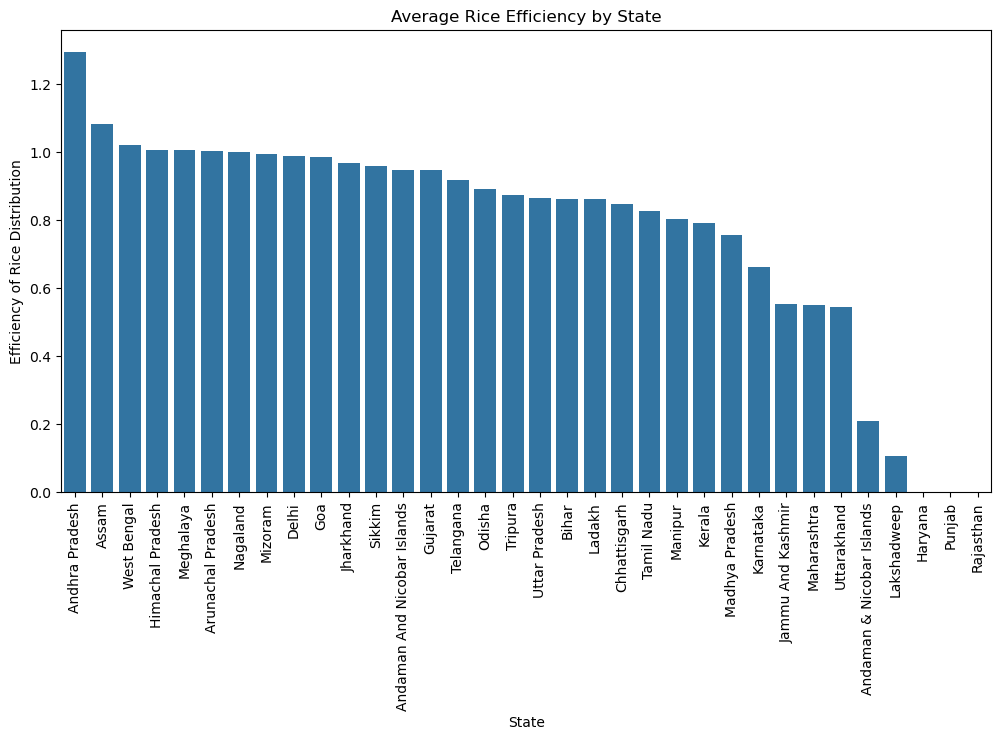

In [56]:
# Visualisation of Efficiency in Rice Distribution
scaling_state_efficiency = scaling_state_efficiency.sort_values(by='Efficiency of Rice distribution', ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x='State (state_name)',y='Efficiency of Rice distribution',data=scaling_state_efficiency)
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Efficiency of Rice Distribution')
plt.title('Average Rice Efficiency by State')
plt.show()

#### Findings:
- Since rice distribution appears more efficient than wheat, rice efficiency was used to identify the best and worst states.
- Andhra Pradesh, Assam, West Bengal, Himachal Pradesh & Meghalaya record the highest efficiency in rice distribution.
- Lakshadweep, Andaman & Nicobar Islands, Uttarakand, Maharashtra & Jammu and Kashmir show the lowest efficiency in rice distribution.

#### 3.Which districts show the highest leakage (low efficiency) in each foodgrain?

In [79]:
worst_rice_district = df.groupby('District (district_name)')['Total Rice Distributed (total_rice_distributed)'].mean().sort_values(ascending =  True).reset_index()
worst_rice_district.head(5)

,District (district_name),Total Rice Distributed (total_rice_distributed)
0,Sikar,0.0
1,Sonipat,0.0
2,Dausa,0.0
3,Patiala,0.0
4,Nuh,0.0


#### Finding:
- Sikar, Sonipat, Dausa, Patiala, Nuh are the top 5 low efficient districts in terms of rice distribution to households.

In [78]:
worst_wheat_district = df.groupby('District (district_name)')['Total Wheat Distritibuted (total_wheat_distributed)'].mean().sort_values(ascending =  True).reset_index()
worst_wheat_district.head(5)

,District (district_name),Total Wheat Distritibuted (total_wheat_distributed)
0,Zunheboto,0.0
1,Adilabad,0.0
2,Bengaluru Urban,0.0
3,Bijapur,0.0
4,Chittoor,0.0


#### Finding:
- Zunheboto, Adilabad, Bengaluru, Bijapur & Chittoor are the top 5 low efficient districts in terms of wheat distribution to households.

#### 4. How does efficiency change over time ?

In [80]:
trend = df.groupby('Month (month)')[['Efficiency of Rice distribution','Efficiency in What distribution']].mean().reset_index()

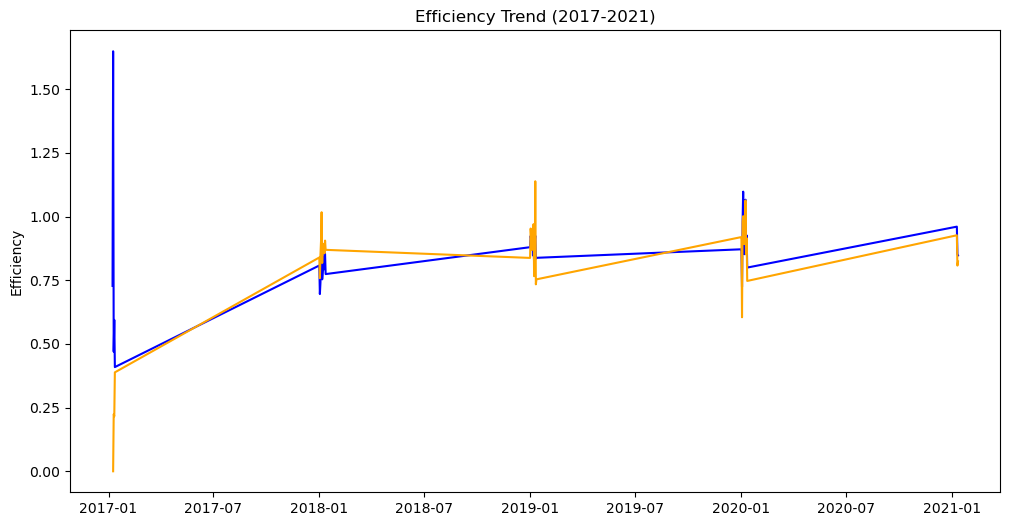

In [85]:
plt.figure(figsize=(12,6))
plt.plot(trend['Month (month)'],trend['Efficiency of Rice distribution'],label='Rice Efficiency',color ='blue')
plt.plot(trend['Month (month)'],trend['Efficiency in What distribution'],label='Wheat Efficiency',color= 'orange')
plt.title('Efficiency Trend (2017-2021)')
plt.ylabel('Efficiency')
plt.show()

#### Findings:
- Efficiency improved began from 2017, ensured a stable growth from 2018 to 2020 but dipped slighty in 2021. External shocks including Covid 19 or transportation restrictions might be athe reasons for sudden decline in 2021.
- Rice generally lead wheat, though wheat narrowed the gap over time.

#### 5. Are rice and wheat efficiencies correlated?

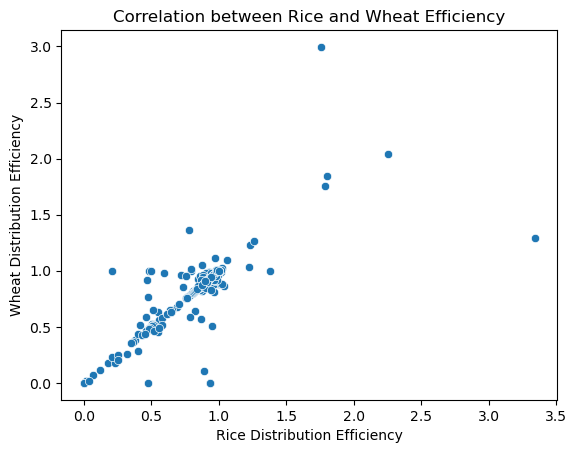

Correlation coefficient: 0.8182090648660395


In [92]:
sns.scatterplot(x='Efficiency of Rice distribution', y='Efficiency in What distribution', data=df)
plt.title("Correlation between Rice and Wheat Efficiency")
plt.xlabel('Rice Distribution Efficiency')
plt.ylabel('Wheat Distribution Efficiency')
plt.show()
print("Correlation coefficient:", df['Efficiency of Rice distribution'].corr(df['Efficiency in What distribution']))

#### Findings:
- The value of Correlation ranges from -1 to 1. Here the value is 0.818 indicates a strong positive correlation.
- This means districts that are efficient in rice distribution tend to be efficient in wheat distribution.
- On the other hand, districts with poor rice efficiency tend to show poor efficiency in wheat distribution.
- This indicates that the efficiency in distribution is depend on governance, logistics, infrastructure.

#### Export as CSV file

In [93]:
# Exporting Cleaned Dataset
df.to_csv("cleaned Monthly District-Wise Public Distribution System Analysis.csv", index=False)
print("CSV file successfully exported!")

CSV file successfully exported!
